In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from workout_intel_core.dataset import load_raw_data

data = load_raw_data()

data.head()

2026-09-25 11:16:04.076 | INFO     | workout_intel_core.config:<module>:11 - PROJ_ROOT path is: C:\Users\Srujan Bali\Documents\Srujan\Programming\Data Science\Workout-Intelligence-Core


,Exercise_Name,muscle_gp,Equipment,Rating
0,Rickshaw Carry,Forearms,Other,9.6
1,Single-Leg Press,Quadriceps,Machine,9.6
2,Landmine twist,Abdominals,Other,9.5
3,Weighted pull-up,Lats,Other,9.5
4,T-Bar Row with Handle,Middle Back,Other,9.5


In [12]:
data.Equipment.unique()

<StringArray>
[        'Other',       'Machine',       'Barbell',      'Dumbbell',
             nan,     'Body Only',   'Kettlebells',         'Cable',
  'E-Z Curl Bar',         'Bands', 'Medicine Ball',        'Cables',
 'Exercise Ball',  'Weight Bench',     'Dumbbells']
Length: 15, dtype: str

<Axes: xlabel='muscle_gp', ylabel='Rating'>

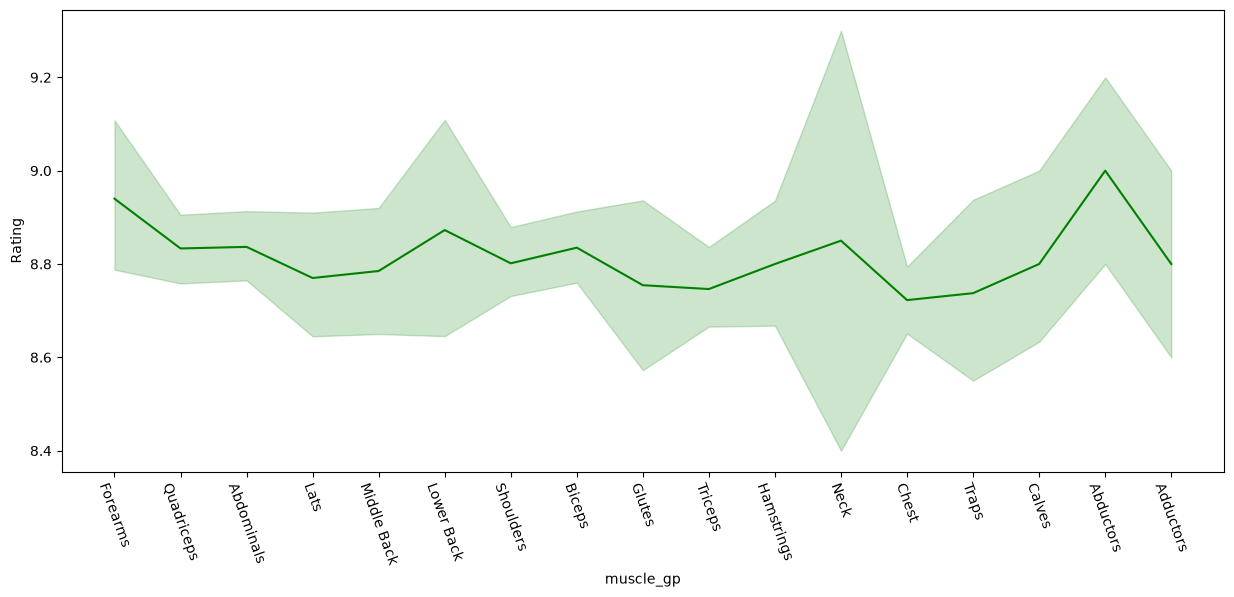

In [3]:
# Variations in the ratings for all muscle groups.
plt.figure(figsize=(15, 6))
plt.xticks(rotation=290)
sns.lineplot(data, x=data.muscle_gp, y=data.Rating, color='green')

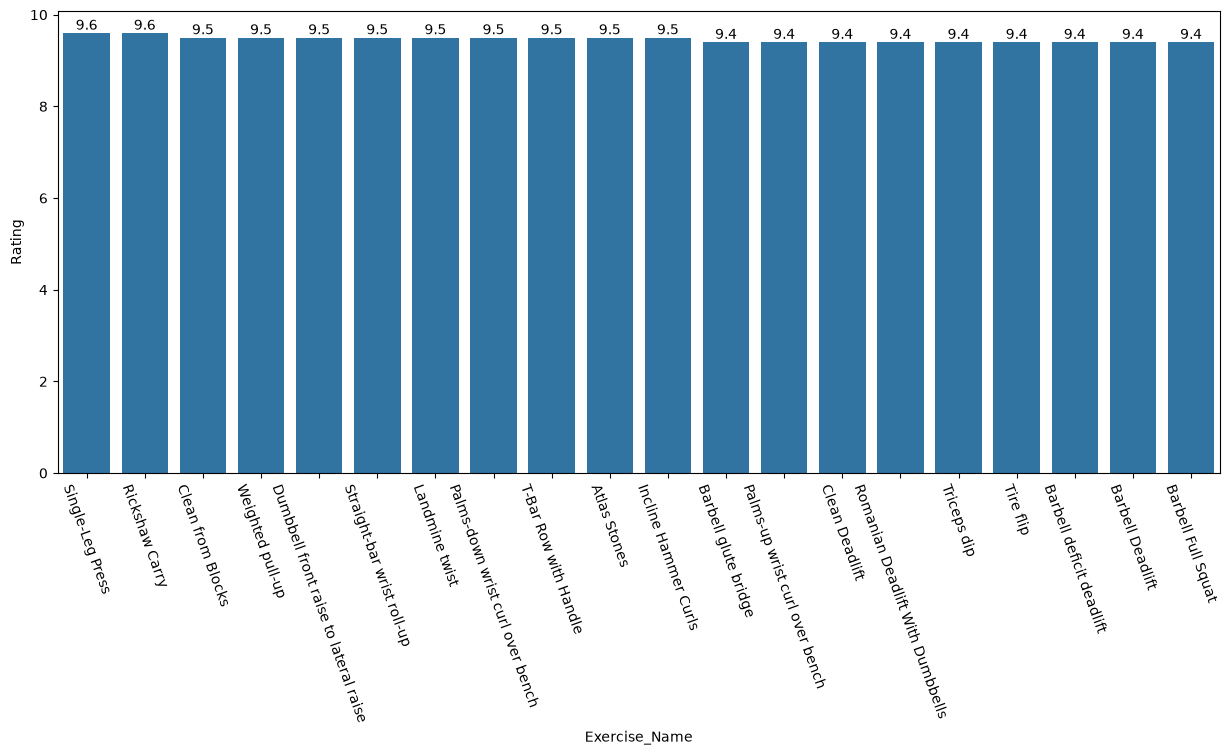

In [4]:
# Top 10 highest rated exericses
plt.figure(figsize=(15, 6))
plt.xticks(rotation=290)
rating_sorted_data = data.sort_values(by="Rating", ascending=False).head(20)
ax = sns.barplot(data=rating_sorted_data, x=rating_sorted_data.Exercise_Name, y=rating_sorted_data.Rating)
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [ ]:
# Cosine similarity matrix to find the best alternatives for exercises provided
from workout_intel_core.features import (
    exercise_feature_matrix,
    compute_similarity_matrix,
    recommend_exercise
)

matrix = exercise_feature_matrix()
similarity_df = compute_similarity_matrix(matrix)

recs = recommend_exercise("Triceps dip", similarity_df, top_n=5)
print(recs)

Exercise_Name
Feet-elevated bench dip              1.0
Parallel Bar Dip                     1.0
Ring dip                             1.0
Push-Ups - Close Triceps Position    1.0
Name: Triceps dip, dtype: float64
